### RaschPy bistretch MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 12 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

The `bistretch` parameterisation combines both stretch axes at once: it restricts the fully-free `bivector` parameterisation (a separate severity per rater x item component plus a separate severity per rater x threshold component) down to just three parameters per rater: a severity shift `lambda_r`, an item-difficulty-stretch `omega_items_r`, and a threshold-stretch `omega_thresholds_r`. It's the natural parsimonious middle ground when a rater shows genuine structure on *both* axes simultaneously – rather than only one, which the `pseudo_halo` and `centrality` parameterisations already cover individually. `omega_items_r`/`omega_thresholds_r` are interpreted exactly as in `pseudo_halo`/`centrality` respectively; `omega_items_r == omega_thresholds_r == 1` is neutral and collapses to the `global` model. Because it's recovered closed-form from an already-calibrated `bivector` fit, it sits strictly between `global` (1 free parameter per rater) and `bivector` (`(I-1)+(K-1)` free parameters per rater) and can be compared against both directly via `model_selection()`.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected – if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Bistretch(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=1234)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:392: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_37397/1221624572.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=1234` makes the simulation fully reproducible – rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data. We simulate under the dedicated `MFRM_Sim_Bistretch` simulator, which generates data with *true* `lambda_r`/`omega_items_r`/`omega_thresholds_r` stretch structure directly, for a genuine parameter recovery check further down.

In [4]:
sim = rp.MFRM_Sim_Bistretch(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=1234)
sim.responses.to_csv('mfrm_bistretch_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_bistretch_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     0.0     0.0     0.0     0.0     0.0     1.0     1.0   
        Person_2     0.0     0.0     1.0     1.0     0.0     1.0     3.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     1.0     0.0      1.0      0.0      0.0  
        Person_2     1.0     1.0      1.0      1.0      1.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the bistretch parameterisation. This first runs the full `bivector` PAIR estimation internally (a separate severity per rater x item component and per rater x threshold component), then closed-form derives each rater's `lambda_r`/`omega_items_r` from the item component and `omega_thresholds_r` from the threshold component – no new estimation. The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_bistretch()

CPU times: user 52.9 ms, sys: 674 μs, total: 53.6 ms
Wall time: 53.5 ms


`lambda_r/omega_items_r/omega_thresholds_r` are recovered per rater via a robust regression of that rater's raw free-model deviation values against the reference item/threshold values, controlled by `regression='huber'` (default) or `regression='theil-sen'`. `'huber'` was the most accurate of several methods tested empirically (see the manual for the comparison); `'theil-sen'` (median of pairwise slopes, fully closed-form) is a close second, with no iterative fit to converge. If `'huber'` fails to converge for a given rater, that rater automatically falls back to `'theil-sen'` with a `UserWarning` naming it – the rest are unaffected:

In [10]:
mfrm_theilsen = rp.MFRM(sim)
mfrm_theilsen.calibrate_bistretch(regression='theil-sen')

Check the item location estimates - view the first two items

In [11]:
mfrm.items.head(2)

Item_1    0.005059
Item_2    0.453277
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) – the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [12]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} Regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                               {round(float(np.sqrt(np.mean((x - y) ** 2))), 3)}')

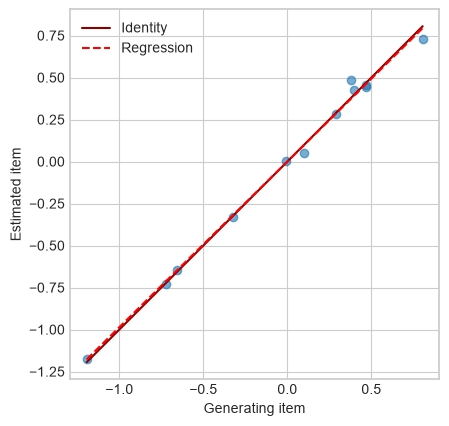

item Pearson correlation:              0.997
item SD ratio (estimated / generating): 0.989
item Regression coefficient:            0.986
item RMSE:                               0.042


In [13]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item', 'my_mfrm_bistretch_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [14]:
%%time
mfrm.item_stats_df_bistretch(full=True)
mfrm.item_stats_bistretch.to_csv('mfrm_bistretch_item_stats.csv')

CPU times: user 54.4 s, sys: 509 ms, total: 54.9 s
Wall time: 55 s


Check the item statistics table

In [15]:
mfrm.item_stats_bistretch

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,0.005,0.044,-0.070,0.092,1600,0.496,0.958,-1.182,0.915,-2.433,0.765,0.762
Item_2,0.453,0.046,0.368,0.546,1600,0.420,1.097,2.647,1.036,1.002,0.744,0.751
Item_3,0.427,0.044,0.345,0.517,1600,0.430,1.158,4.209,1.122,3.292,0.744,0.752
Item_4,0.281,0.041,0.205,0.365,1600,0.442,0.991,-0.229,0.995,-0.130,0.750,0.757
Item_5,0.443,0.041,0.361,0.524,1600,0.425,1.002,0.071,0.980,-0.557,0.751,0.752
Item_6,0.052,0.038,-0.023,0.128,1600,0.480,1.083,2.262,1.047,1.306,0.752,0.762
Item_7,-0.727,0.042,-0.812,-0.648,1600,0.618,0.964,-1.016,0.948,-1.470,0.758,0.757
Item_8,-1.175,0.056,-1.290,-1.075,1600,0.687,0.953,-1.311,0.918,-2.332,0.751,0.740
Item_9,0.732,0.042,0.643,0.809,1600,0.366,0.969,-0.855,0.961,-1.088,0.736,0.738
Item_10,-0.330,0.041,-0.409,-0.252,1600,0.549,1.017,0.488,1.011,0.311,0.760,0.763


Generate a table of threshold statistics (and check run time), and save to file

In [16]:
%%time
mfrm.threshold_stats_df_bistretch(full=True)
mfrm.threshold_stats_bistretch.to_csv('mfrm_bistretch_threshold_stats.csv')

CPU times: user 115 ms, sys: 2.63 ms, total: 118 ms
Wall time: 118 ms


Check the threshold statistics table

In [17]:
mfrm.threshold_stats_bistretch

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-2.020,0.049,-2.098,-1.911,1.016,1.324,1.022,1.044,0.968,0.575,0.590
Threshold 2,-0.066,0.036,-0.135,0.001,1.002,0.147,0.986,-0.718,1.002,0.448,0.483
Threshold 3,0.257,0.035,0.195,0.324,0.995,-0.435,0.990,-0.676,1.020,0.314,0.323
Threshold 4,0.393,0.039,0.308,0.465,0.997,-0.290,0.992,-0.465,1.012,0.340,0.344
Threshold 5,1.436,0.049,1.323,1.517,1.002,0.194,0.996,-0.237,0.995,0.490,0.482


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

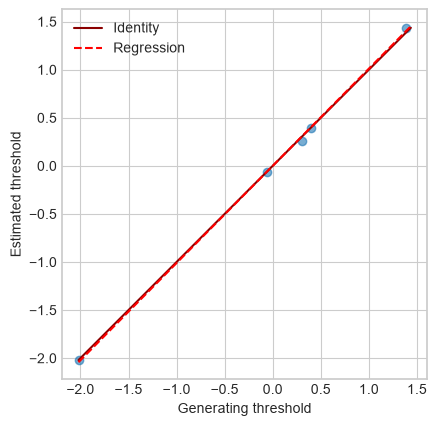

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 1.011
threshold Regression coefficient:            1.011
threshold RMSE:                               0.031


In [18]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_bistretch_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [19]:
%%time
mfrm.rater_stats_df_bistretch()
mfrm.rater_stats_bistretch.to_csv('mfrm_bistretch_rater_stats.csv')
mfrm.rater_stats_bistretch_full_vector.to_csv('mfrm_bistretch_rater_stats_full_vector.csv')

CPU times: user 66.4 ms, sys: 1.47 ms, total: 67.8 ms
Wall time: 67.8 ms


Check the rater statistics table

In [20]:
mfrm.rater_stats_bistretch

lambda        omega_items        omega_thresholds         \
        Estimate     SE    Estimate     SE         Estimate     SE   
Rater_1    1.031  0.048       1.161  0.079            1.203  0.042   
Rater_2   -0.162  0.039       0.681  0.067            0.794  0.029   
Rater_3    1.132  0.053       0.892  0.084            0.652  0.036   
Rater_4   -0.397  0.049       0.676  0.064            1.441  0.042   
Rater_5   -0.210  0.057       1.458  0.080            0.408  0.036   
Rater_6   -0.746  0.040       1.271  0.068            1.140  0.035   
Rater_7   -0.383  0.040       0.961  0.053            1.200  0.035   
Rater_8   -0.258  0.037       0.876  0.064            1.160  0.031   

        Overall statistics                     
                     Count Infit MS Outfit MS  
Rater_1             2400.0    0.992     0.950  
Rater_2             2400.0    0.976     0.941  
Rater_3             2400.0    1.089     1.010  
Rater_4             2400.0    1.017     0.999  
Rater_5             2400.0    1.039     1.050  
Rater_6             2400.0    0.987     0.965  
Rater_7             2400.0    1.076     1.052  
Rater_8             2400.0    0.991     0.964

`self.rater_stats_bistretch` (above) is the model's own raw shift/stretch parameters (`lambda`, `omega_items`, `omega_thresholds`), each with its own bootstrap SE. The same call also stores the reconstructed full severity vector separately.

In [21]:
mfrm.rater_stats_bistretch_full_vector

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    1.032  0.049    1.104  0.061    1.100  0.060    1.077  0.055   
Rater_2   -0.164  0.041   -0.307  0.048   -0.299  0.050   -0.252  0.043   
Rater_3    1.131  0.054    1.083  0.072    1.086  0.070    1.101  0.062   
Rater_4   -0.398  0.051   -0.544  0.055   -0.535  0.055   -0.488  0.053   
Rater_5   -0.208  0.059   -0.003  0.070   -0.015  0.067   -0.082  0.063   
Rater_6   -0.745  0.043   -0.623  0.047   -0.630  0.047   -0.670  0.042   
Rater_7   -0.383  0.040   -0.401  0.046   -0.400  0.045   -0.394  0.042   
Rater_8   -0.258  0.037   -0.314  0.046   -0.311  0.044   -0.293  0.040   

          Item_5         ... Threshold 2 Threshold 3        Threshold 4  \
        Estimate     SE  ...          SE    Estimate     SE    Estimate   
Rater_1    1.103  0.060  ...       0.033       0.052  0.038       0.080   
Rater_2   -0.304  0.048  ...       0.020      -0.040  0.023      -0.068   
Rater_3    1.084  0.071  ...       0.025      -0.090  0.028      -0.137   
Rater_4   -0.540  0.057  ...       0.027       0.120  0.031       0.180   
Rater_5   -0.008  0.072  ...       0.030      -0.138  0.029      -0.219   
Rater_6   -0.626  0.048  ...       0.018       0.036  0.019       0.055   
Rater_7   -0.400  0.046  ...       0.022       0.049  0.026       0.076   
Rater_8   -0.313  0.046  ...       0.016       0.038  0.018       0.060   

               Threshold 5        Overall statistics                     
            SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.041       0.292  0.076             2400.0    0.992     0.950  
Rater_2  0.024      -0.283  0.047             2400.0    0.976     0.941  
Rater_3  0.031      -0.500  0.055             2400.0    1.089     1.010  
Rater_4  0.035       0.641  0.067             2400.0    1.017     0.999  
Rater_5  0.030      -0.836  0.054             2400.0    1.039     1.050  
Rater_6  0.021       0.201  0.051             2400.0    0.987     0.965  
Rater_7  0.029       0.285  0.055             2400.0    1.076     1.052  
Rater_8  0.022       0.227  0.049             2400.0    0.991     0.964  

[8 rows x 37 columns]

The three parameters `lambda_bistretch` (severity shift), `omega_items_bistretch` (item-difficulty stretch) and `omega_thresholds_bistretch` (threshold stretch) are the actual summary the model produces – `mfrm.raters_bistretch` above is just their reconstruction back into full (rater x item) x threshold form, for compatibility with all the same downstream fit-statistic and plotting machinery the other rater parameterisations use. The term `lambda` is used for the global severity since it is an additive parameter, as for instance in the `bivector` model, so `lambda` is consistent with the notation used elsewhere in the package. `omega` is used for both stretch parameters, following Jin & Wang (2018)'s own notation for a rater stretch factor – each is a multiplicative parameter rather than an additive one, so together they deserve a distinct Greek letter from the shift. A rater near `omega_items=1`/`omega_thresholds=1` is showing undistorted perceptions on that axis; departures above or below 1 carry the same interpretation as the corresponding single-axis `pseudo_halo`/`centrality` parameter.

In [22]:
pd.DataFrame({'lambda (severity)': mfrm.lambda_bistretch, 'omega_items (item stretch)': mfrm.omega_items_bistretch, 'omega_thresholds (threshold stretch)': mfrm.omega_thresholds_bistretch}).round(3)

,lambda (severity),omega_items (item stretch),omega_thresholds (threshold stretch)
Rater_1,1.031,1.161,1.203
Rater_2,-0.162,0.681,0.794
Rater_3,1.132,0.892,0.652
Rater_4,-0.397,0.676,1.441
Rater_5,-0.210,1.458,0.408
Rater_6,-0.746,1.271,1.140
Rater_7,-0.383,0.961,1.200
Rater_8,-0.258,0.876,1.160


Pass `alias=True` to `rater_stats_df_bistretch()` to relabel these columns with a human-readable name instead of the raw parameter names: `'Global'` for `lambda`, `'Item stretch'` for `omega_items`, `'Threshold stretch'` for `omega_thresholds` – purely cosmetic, values remain unchanged:

In [23]:
mfrm.rater_stats_df_bistretch(alias=True)
mfrm.rater_stats_bistretch

Global        Item stretch        Threshold stretch         \
        Estimate     SE     Estimate     SE          Estimate     SE   
Rater_1    1.031  0.048        1.161  0.079             1.203  0.042   
Rater_2   -0.162  0.039        0.681  0.067             0.794  0.029   
Rater_3    1.132  0.053        0.892  0.084             0.652  0.036   
Rater_4   -0.397  0.049        0.676  0.064             1.441  0.042   
Rater_5   -0.210  0.057        1.458  0.080             0.408  0.036   
Rater_6   -0.746  0.040        1.271  0.068             1.140  0.035   
Rater_7   -0.383  0.040        0.961  0.053             1.200  0.035   
Rater_8   -0.258  0.037        0.876  0.064             1.160  0.031   

        Overall statistics                     
                     Count Infit MS Outfit MS  
Rater_1             2400.0    0.992     0.950  
Rater_2             2400.0    0.976     0.941  
Rater_3             2400.0    1.089     1.010  
Rater_4             2400.0    1.017     0.999  
Rater_5             2400.0    1.039     1.050  
Rater_6             2400.0    0.987     0.965  
Rater_7             2400.0    1.076     1.052  
Rater_8             2400.0    0.991     0.964

Since `bistretch` restricts both axes at once, the divergence test runs twice – once against `bivector`'s own item marginal, once against its threshold marginal – giving separate `'Flagged items'` and `'Flagged categories'` columns:

`divergence_test='wald'` references the test statistic against the standard normal distribution; `divergence_test='t'` uses a plain Student's t-distribution with `no_of_samples - 1` degrees of freedom instead, correcting (a little) for finite-bootstrap-sample uncertainty in the SE estimate itself. In practice `'t'` only matters if `no_of_samples` has deliberately been dropped for speed – at `no_of_samples=300` or more, `'wald'` and `'t'` give essentially the same p-values. If you're not economising on `no_of_samples`, there's no reason to prefer `'t'` over `'wald'`; just use `'wald'` (optionally with a larger `no_of_samples`, which improves the underlying SE estimate itself rather than just widening the reference distribution around it).

Passing `full=True` adds one plain True/False column per item and threshold to the primary table itself, directly after the `'Flagged items'/'Flagged categories'` count, for scanning flagged status across all elements at a glance – and `rater_stats_bistretch_full_vector` receives a per-element `'Flagged'` column added to each threshold's own `Estimate`/`SE`/CI block displaying the same information alongside. The full `mfrm.rater_stats_bistretch` is displayed here transposed using `.T` for visual convenience.

In [24]:
mfrm.rater_stats_df_bistretch(full=True, divergence_test='wald', correction='bh')
mfrm.rater_stats_bistretch.T

Rater_1 Rater_2 Rater_3 Rater_4 Rater_5 Rater_6  \
lambda             Estimate    1.031  -0.162   1.132  -0.397   -0.21  -0.746   
                   SE          0.049   0.039   0.056   0.046   0.051   0.041   
                   2.5%        0.948  -0.243    1.03  -0.496  -0.314  -0.824   
                   97.5%       1.132  -0.091   1.247  -0.314  -0.118  -0.669   
omega_items        Estimate    1.161   0.681   0.892   0.676   1.458   1.271   
                   SE          0.083   0.063   0.079   0.064   0.081   0.071   
                   2.5%        1.024   0.552   0.729   0.557   1.302   1.119   
                   97.5%        1.34   0.809   1.036   0.803   1.619   1.409   
omega_thresholds   Estimate    1.203   0.794   0.652   1.441   0.408    1.14   
                   SE          0.041   0.029   0.037   0.042   0.036   0.036   
                   2.5%        1.133   0.733   0.575   1.373   0.327   1.079   
                   97.5%       1.288   0.847   0.715   1.527    0.47   1.216   
Flagged items      Count         0.0     0.0     0.0     0.0     0.0     0.0   
Flagged categories Count         0.0     0.0     0.0     0.0     0.0     0.0   
Item_1             Flagged     False   False   False   False   False   False   
Item_2             Flagged     False   False   False   False   False   False   
Item_3             Flagged     False   False   False   False   False   False   
Item_4             Flagged     False   False   False   False   False   False   
Item_5             Flagged     False   False   False   False   False   False   
Item_6             Flagged     False   False   False   False   False   False   
Item_7             Flagged     False   False   False   False   False   False   
Item_8             Flagged     False   False   False   False   False   False   
Item_9             Flagged     False   False   False   False   False   False   
Item_10            Flagged     False   False   False   False   False   False   
Item_11            Flagged     False   False   False   False   False   False   
Item_12            Flagged     False   False   False   False   False   False   
Threshold 1        Flagged     False   False   False   False   False   False   
Threshold 2        Flagged     False   False   False   False   False   False   
Threshold 3        Flagged     False   False   False   False   False   False   
Threshold 4        Flagged     False   False   False   False   False   False   
Threshold 5        Flagged     False   False   False   False   False   False   
Overall statistics Count      2400.0  2400.0  2400.0  2400.0  2400.0  2400.0   
                   Infit MS    0.992   0.976   1.089   1.017   1.039   0.987   
                   Infit Z    -0.252  -0.753   2.506   0.568   1.114  -0.405   
                   Outfit MS    0.95   0.941    1.01   0.999    1.05   0.965   
                   Outfit Z   -1.437  -1.478    0.21  -0.035   0.896  -0.862   

                             Rater_7 Rater_8  
lambda             Estimate   -0.383  -0.258  
                   SE          0.039   0.038  
                   2.5%       -0.466   -0.34  
                   97.5%      -0.311  -0.193  
omega_items        Estimate    0.961   0.876  
                   SE          0.052   0.064  
                   2.5%        0.858   0.761  
                   97.5%       1.069   1.008  
omega_thresholds   Estimate      1.2    1.16  
                   SE          0.032   0.029  
                   2.5%        1.143   1.108  
                   97.5%       1.275   1.216  
Flagged items      Count         0.0     0.0  
Flagged categories Count         0.0     0.0  
Item_1             Flagged     False   False  
Item_2             Flagged     False   False  
Item_3             Flagged     False   False  
Item_4             Flagged     False   False  
Item_5             Flagged     False   False  
Item_6             Flagged     False   False  
Item_7             Flagged     False   False  
Item_8             Flagged     Fal

Recovery check on the model's `mfrm.generating.lambda_`, `mfrm.generating.omega_items` and `mfrm.generating.omega_thresholds` parameters. Plotted separately since they are on different scales:

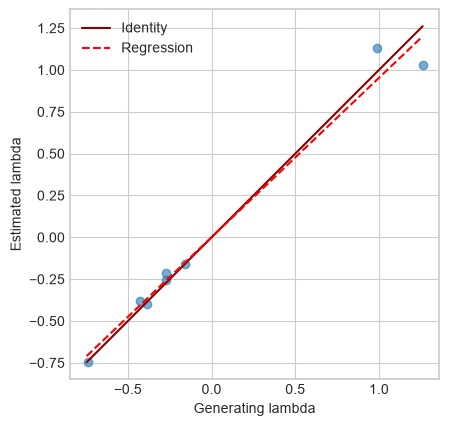

lambda Pearson correlation:              0.989
lambda SD ratio (estimated / generating): 0.962
lambda Regression coefficient:            0.952
lambda RMSE:                               0.1


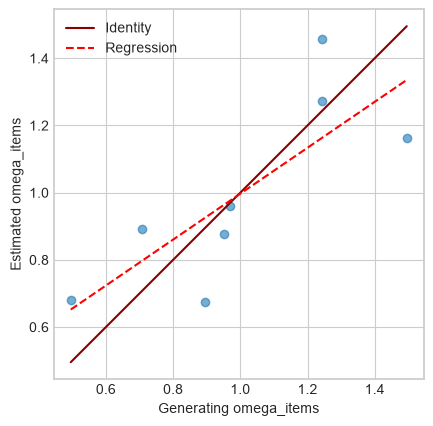

omega_items Pearson correlation:              0.785
omega_items SD ratio (estimated / generating): 0.871
omega_items Regression coefficient:            0.683
omega_items RMSE:                               0.187


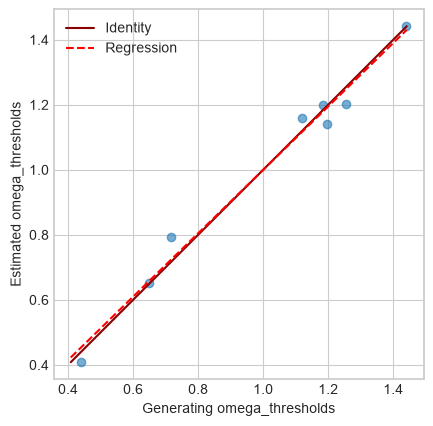

omega_thresholds Pearson correlation:              0.991
omega_thresholds SD ratio (estimated / generating): 0.984
omega_thresholds Regression coefficient:            0.975
omega_thresholds RMSE:                               0.043


In [25]:
recovery_plot(mfrm.generating.lambda_, mfrm.lambda_bistretch, 'lambda', 'my_mfrm_bistretch_lambda_recovery.png')
recovery_plot(mfrm.generating.omega_items, mfrm.omega_items_bistretch, 'omega_items', 'my_mfrm_bistretch_omega_items_recovery.png')
recovery_plot(mfrm.generating.omega_thresholds, mfrm.omega_thresholds_bistretch, 'omega_thresholds', 'my_mfrm_bistretch_omega_thresholds_recovery.png')

And the correlations between true and estimated values for each parameter:

In [26]:
for param, sim_attr in [('lambda', 'lambda_'), ('omega_items', 'omega_items'), ('omega_thresholds', 'omega_thresholds')]:
    true_vals = getattr(sim, sim_attr)
    est_vals = getattr(mfrm, f'{param}_bistretch')
    r = np.corrcoef(true_vals, est_vals.reindex(true_vals.index))[0, 1]
    print(f'{param}: r = {r:.3f}')

lambda: r = 0.989
omega_items: r = 0.785
omega_thresholds: r = 0.991


Generate a table of person statistics (and check run time), and save to file

In [27]:
%%time
mfrm.person_stats_df_bistretch(full=True)
mfrm.person_stats_bistretch.to_csv('mfrm_bistretch_person_stats.csv')

CPU times: user 20.3 ms, sys: 959 μs, total: 21.3 ms
Wall time: 21.2 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [28]:
mfrm.person_stats_bistretch.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,-2.808,0.192,0.183,41,480,0.085,0.908,0.724,-0.401,-0.839
Person_2,-0.067,0.094,0.095,218,480,0.454,1.011,0.987,0.126,-0.041
Person_3,1.009,0.101,0.113,338,480,0.704,1.242,1.264,1.535,1.526
Person_4,0.117,0.093,0.094,239,480,0.498,1.021,0.988,0.200,-0.034
Person_5,1.146,0.104,0.107,351,480,0.731,1.057,1.047,0.411,0.328
Person_6,4.209,0.351,0.322,472,480,0.983,0.840,0.436,-0.326,-0.045
Person_7,-2.023,0.153,0.159,68,480,0.142,1.080,1.233,0.463,1.153
Person_8,1.328,0.109,0.113,367,480,0.765,1.080,1.166,0.536,0.935
Person_9,-2.600,0.181,0.157,47,480,0.098,0.755,0.704,-1.246,-1.406
Person_10,0.409,0.093,0.094,273,480,0.569,1.025,1.023,0.228,0.206


And the same recovery check for person locations, against `mfrm.generating.persons`:

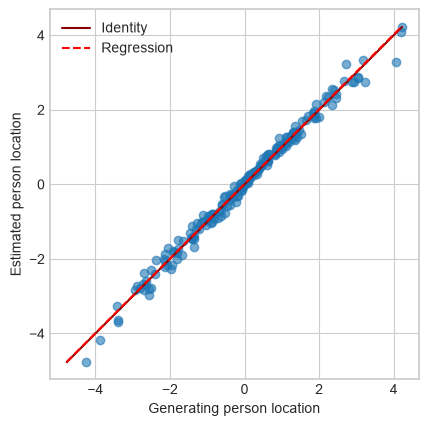

person location Pearson correlation:              0.995
person location SD ratio (estimated / generating): 1.006
person location Regression coefficient:            1.001
person location RMSE:                               0.159


In [29]:
recovery_plot(mfrm.generating.persons, mfrm.persons_bistretch, 'person location', 'my_mfrm_bistretch_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [30]:
%%time
mfrm.test_stats_df_bistretch()
mfrm.test_stats_bistretch.to_csv('mfrm_bistretch_test_stats.csv')

CPU times: user 3.39 ms, sys: 644 μs, total: 4.04 ms
Wall time: 3.89 ms


Check the test statistics table

In [31]:
mfrm.test_stats_bistretch

,Items,Persons
Mean,-0.000,0.014
SD,0.594,1.631
Separation ratio,13.463,12.250
Strata,18.284,16.667
Reliability,0.995,0.993


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [32]:
%%time
mfrm.item_res_corr_analysis_bistretch()
mfrm.item_residual_correlations_bistretch.to_csv('mfrm_bistretch_item_residual_correlations.csv')
mfrm.item_loadings_bistretch.to_csv('mfrm_bistretch_item_loadings.csv')

CPU times: user 7.51 ms, sys: 2.42 ms, total: 9.93 ms
Wall time: 11.3 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [33]:
round(mfrm.item_residual_correlations_bistretch, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,0.038,-0.013,0.007,0.055,-0.013,-0.051,0.019,0.002,0.035,-0.007,-0.017
Item_2,0.038,1.000,0.005,-0.031,0.029,-0.022,-0.011,-0.005,-0.001,-0.056,0.039,-0.012
Item_3,-0.013,0.005,1.000,-0.012,0.024,0.010,-0.019,-0.017,0.018,-0.030,0.006,-0.017
Item_4,0.007,-0.031,-0.012,1.000,-0.017,0.024,-0.021,-0.033,0.026,0.039,0.015,-0.015
Item_5,0.055,0.029,0.024,-0.017,1.000,-0.039,0.004,-0.009,0.007,-0.060,0.015,0.001
Item_6,-0.013,-0.022,0.010,0.024,-0.039,1.000,-0.018,0.013,0.016,0.034,-0.015,-0.011
Item_7,-0.051,-0.011,-0.019,-0.021,0.004,-0.018,1.000,-0.047,-0.033,-0.004,-0.009,-0.009
Item_8,0.019,-0.005,-0.017,-0.033,-0.009,0.013,-0.047,1.000,-0.007,-0.054,-0.017,0.035
Item_9,0.002,-0.001,0.018,0.026,0.007,0.016,-0.033,-0.007,1.000,-0.001,-0.016,-0.044
Item_10,0.035,-0.056,-0.030,0.039,-0.060,0.034,-0.004,-0.054,-0.001,1.000,-0.026,-0.008


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [34]:
round(mfrm.item_loadings_bistretch['PC 1'], 3)

Item_1    -0.035
Item_2    -0.142
Item_3    -0.039
Item_4     0.129
Item_5    -0.145
Item_6     0.125
Item_7     0.007
Item_8    -0.060
Item_9     0.045
Item_10    0.192
Item_11   -0.065
Item_12   -0.030
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [35]:
%%time
mfrm.rater_res_corr_analysis_bistretch()
mfrm.rater_residual_correlations_bistretch.to_csv('mfrm_bistretch_rater_residual_correlations.csv')
mfrm.rater_loadings_bistretch.to_csv('mfrm_bistretch_rater_loadings.csv')

CPU times: user 13.8 ms, sys: 848 μs, total: 14.6 ms
Wall time: 14.5 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [36]:
round(mfrm.rater_residual_correlations_bistretch, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,0.004,-0.049,0.020,-0.026,0.040,0.011,-0.006
Rater_2,0.004,1.000,0.011,-0.028,-0.005,0.011,0.007,0.001
Rater_3,-0.049,0.011,1.000,-0.057,0.000,-0.010,-0.042,0.014
Rater_4,0.020,-0.028,-0.057,1.000,-0.055,-0.010,-0.028,-0.030
Rater_5,-0.026,-0.005,0.000,-0.055,1.000,-0.002,-0.056,0.046
Rater_6,0.040,0.011,-0.010,-0.010,-0.002,1.000,-0.023,-0.078
Rater_7,0.011,0.007,-0.042,-0.028,-0.056,-0.023,1.000,-0.039
Rater_8,-0.006,0.001,0.014,-0.030,0.046,-0.078,-0.039,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [37]:
round(mfrm.rater_loadings_bistretch['PC 1'], 3)

Rater_1    0.184
Rater_2   -0.017
Rater_3   -0.178
Rater_4    0.145
Rater_5   -0.178
Rater_6    0.160
Rater_7    0.065
Rater_8   -0.184
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

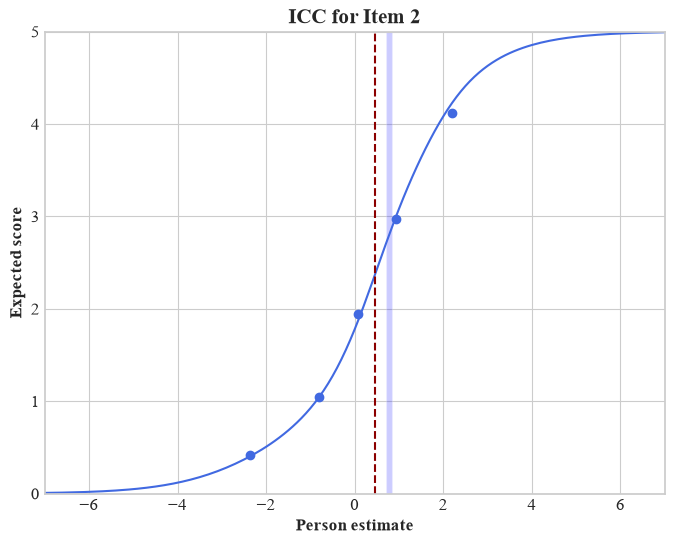

In [38]:
mfrm.icc_bistretch('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_bistretch_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

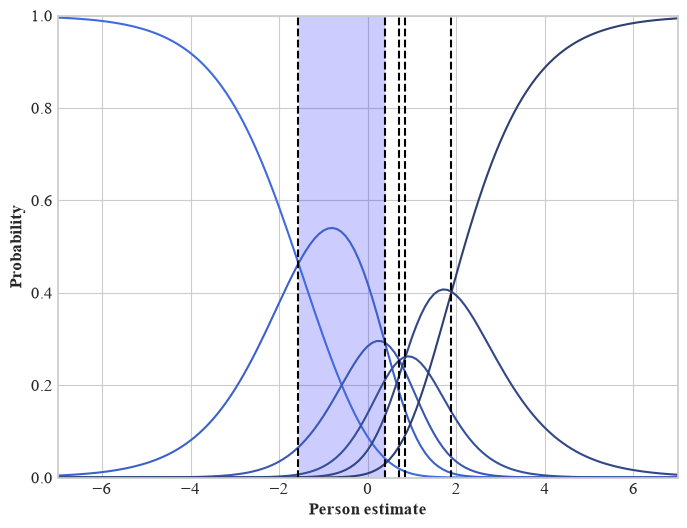

In [39]:
mfrm.crcs_bistretch('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_bistretch_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

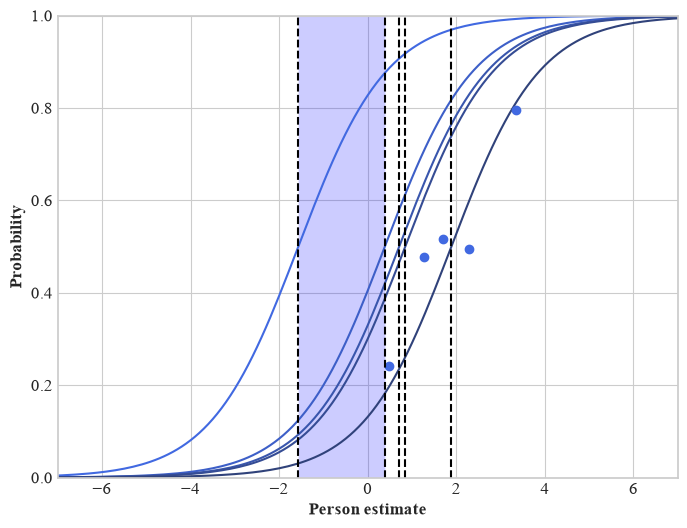

In [40]:
mfrm.threshold_ccs_bistretch('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_bistretch_threshold_ccs')

Produce an item information function curve for Item 2

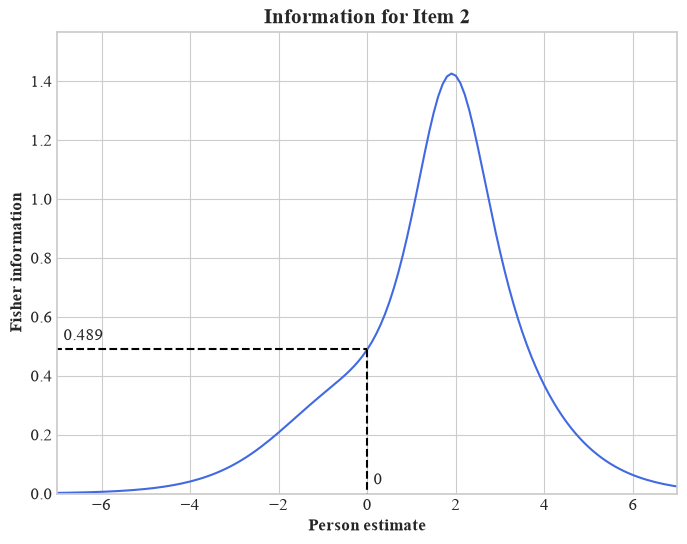

In [41]:
mfrm.iic_bistretch('Item_2', point_info_lines=[0], point_info_labels=True,
                   title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_bistretch_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

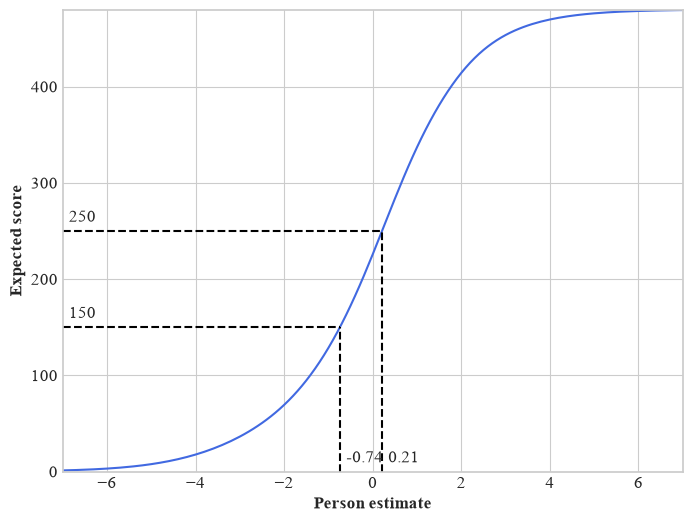

In [42]:
mfrm.tcc_bistretch(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_bistretch_tcc')

Produce a test information curve

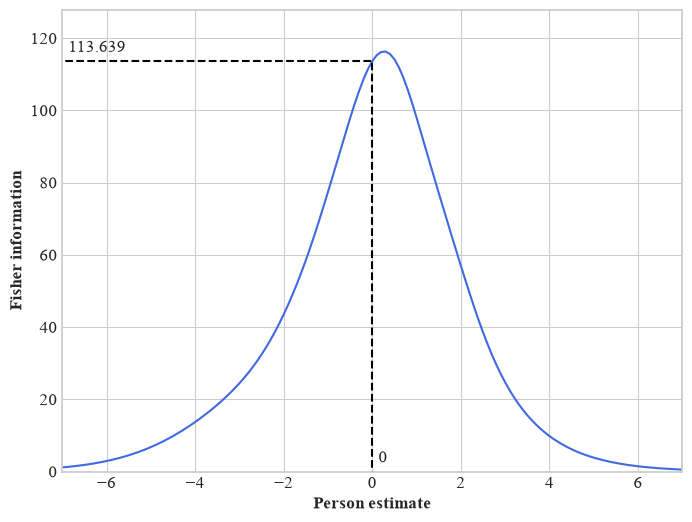

In [43]:
mfrm.test_info_bistretch(point_info_lines=[0], point_info_labels=True, xmin=-7, xmax=7, filename='my_mfrm_bistretch_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

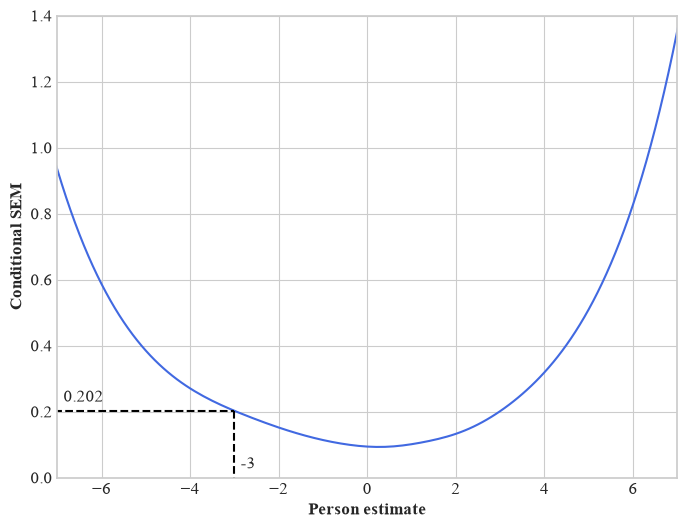

In [44]:
mfrm.test_csem_bistretch(point_csem_lines=[-3], point_csem_labels=True,
                         ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_bistretch_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

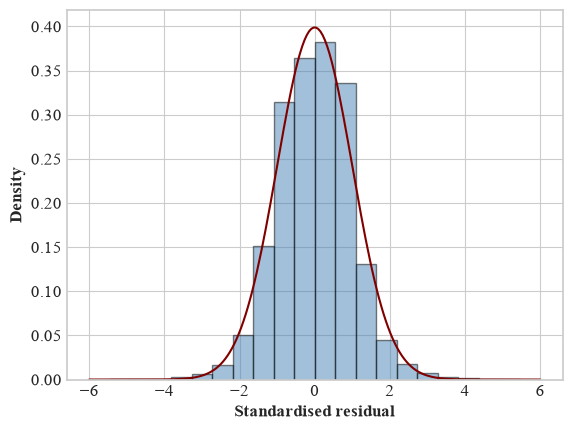

In [45]:
mfrm.std_residuals_plot_bistretch(bin_width=0.6, normal=True, filename='my_mfrm_bistretch_std_residuals_plot')

**Model selection.** Since `bistretch` is nested between `global` and `bivector` (and can also be compared directly against `centrality`/`pseudo_halo`), `model_selection()` can compare all eight MFRM rater representations directly via AIC, BIC, or LR. See the `Model selection` example notebook for a full worked demonstration, including a direct three-way comparison of the stretch representations (`models=['centrality', 'pseudo_halo', 'bistretch']`).

Run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [46]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_bistretch_anchor(anchors)

CPU times: user 44.1 ms, sys: 555 μs, total: 44.6 ms
Wall time: 44.2 ms


Check the anchored item locations against the unanchored ones.

In [47]:
item_check = pd.DataFrame({'Unanchored': mfrm.items,
                           'Anchored': mfrm.anchor_items_bistretch})
round(item_check, 3)

,Unanchored,Anchored
Item_1,0.005,-0.013
Item_2,0.453,0.353
Item_3,0.427,0.293
Item_4,0.281,0.231
Item_5,0.443,0.379
Item_6,0.052,-0.019
Item_7,-0.727,-0.618
Item_8,-1.175,-1.014
Item_9,0.732,0.637
Item_10,-0.330,-0.204


Check the anchored thresholds against the unanchored thresholds.

In [48]:
threshold_check = pd.DataFrame({'Unanchored': mfrm.thresholds,
                           'Anchored': mfrm.anchor_thresholds_bistretch})
round(threshold_check, 3)

,Unanchored,Anchored
1,-2.020,-2.076
2,-0.066,-0.027
3,0.257,0.265
4,0.393,0.379
5,1.436,1.459


Check the anchored rater x item x threshold severities against the unanchored ones (two separate dataframes).

In [49]:
round(mfrm.raters_bistretch, 3)

1      2      3      4      5
rater   item                                      
Rater_1 Item_1   0.622  1.019  1.084  1.112  1.324
        Item_2   0.694  1.091  1.157  1.184  1.396
        Item_3   0.690  1.087  1.152  1.180  1.392
        Item_4   0.667  1.063  1.129  1.156  1.368
        Item_5   0.693  1.089  1.155  1.183  1.394
...                ...    ...    ...    ...    ...
Rater_8 Item_8  -0.438 -0.125 -0.073 -0.052  0.115
        Item_9  -0.675 -0.362 -0.310 -0.288 -0.121
        Item_10 -0.543 -0.230 -0.178 -0.156  0.010
        Item_11 -0.644 -0.331 -0.280 -0.258 -0.091
        Item_12 -0.503 -0.191 -0.139 -0.117  0.050

[96 rows x 5 columns]

In [50]:
round(mfrm.anchor_raters_bistretch, 3)

1      2      3      4      5
rater   item                                      
Rater_1 Item_1   0.282  0.649  0.701  0.721  0.914
        Item_2   0.407  0.773  0.825  0.846  1.039
        Item_3   0.387  0.753  0.805  0.826  1.019
        Item_4   0.365  0.732  0.784  0.804  0.997
        Item_5   0.416  0.782  0.834  0.855  1.048
...                ...    ...    ...    ...    ...
Rater_8 Item_8  -0.947 -0.673 -0.633 -0.618 -0.474
        Item_9  -0.951 -0.676 -0.637 -0.622 -0.477
        Item_10 -0.949 -0.674 -0.635 -0.620 -0.476
        Item_11 -0.950 -0.676 -0.637 -0.622 -0.477
        Item_12 -0.948 -0.674 -0.634 -0.619 -0.475

[96 rows x 5 columns]